In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

bank = pd.read_csv('bank-full.csv', sep=';')

In [6]:
print(bank.head())

bank.info()
print(bank.describe())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #

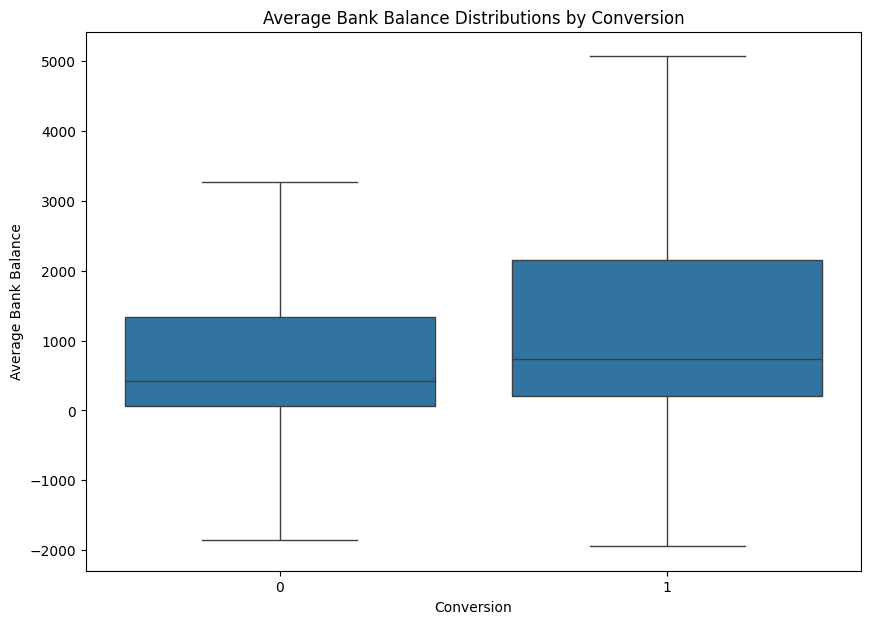

In [7]:
bank['converted'] = bank['y'].apply(lambda x: 0 if x == 'no' else 1)
bank.drop('y', axis=1, inplace=True)

plt.figure(figsize=(10, 7))
sns.boxplot(x='converted', y='balance', data=bank, showfliers=False)
plt.xlabel('Conversion')
plt.ylabel('Average Bank Balance')
plt.title('Average Bank Balance Distributions by Conversion')
plt.show()

cat_cols = bank.select_dtypes(include=['object']).columns
bank = pd.get_dummies(data=bank, columns=cat_cols, drop_first=True)

In [8]:
X = bank.drop('converted', axis=1)
y = bank['converted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dec_tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dec_tree_model.fit(X_train, y_train)

y_pred = dec_tree_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9009879091713359
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     11966
           1       0.65      0.35      0.45      1598

    accuracy                           0.90     13564
   macro avg       0.78      0.66      0.70     13564
weighted avg       0.89      0.90      0.89     13564

